# Few-shot Learning

Test accuracy of the expand-and-sparsify classification pipeline as a function of the number of training exposures per category.

Training is done by the stand-alone script `r3_few_shot_training.py`, which pickles the results to `data/r3_few_shot_results.pkl`. This notebook loads those results and generates the figures.

In [23]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

## Load results

Run `python r3_few_shot_training.py` from the repo root to (re)generate the pickle.

In [24]:
with open('data/r3_few_shot_results.pkl', 'rb') as f:
    results = pickle.load(f)

params = results['params']
single = results['single']
binary = results['binary']

all_train_accs_single    = single['train_accs']
all_test_accs_single     = single['test_accs']
all_test_accs_single_svm = single['test_accs_svm']

all_train_accs_binary    = binary['train_accs']
all_test_accs_binary     = binary['test_accs']
all_test_accs_binary_svm = binary['test_accs_svm']

print(f"Parameters: {params}")
print(f"Single — shape: {all_test_accs_single.shape}, picks: {single['n_picks']}")
print(f"Binary — shape: {all_test_accs_binary.shape}, picks: {binary['n_picks']}")

Parameters: {'n_hd': 10000, 'p_hd': 0.025, 'd': 0.5, 'p': 0.01, 'normalized': 'raw', 'n_times': 10}
Single — shape: (10, 148), picks: 148
Binary — shape: (10, 100), picks: 100


## Results

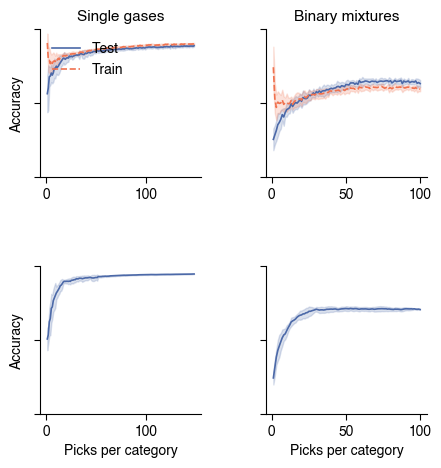

In [25]:
fig, ax = plt.subplots(2, 2, figsize=(5, 5),
                       gridspec_kw={'wspace': 0.4, 'hspace': 0.6},
                       sharey='row')

picks = np.arange(1, all_test_accs_single.shape[1] + 1)
picks_b = np.arange(1, all_test_accs_binary.shape[1] + 1)

# --- Row 1: Expand & Sparsify ---
# Single gases
ax0 = ax[0, 0]
mean_test = all_test_accs_single.mean(axis=0)
std_test  = all_test_accs_single.std(axis=0)
mean_train = all_train_accs_single.mean(axis=0)
std_train  = all_train_accs_single.std(axis=0)
ax0.plot(picks, mean_test, '-', color='C0', label='Test', clip_on=False)
ax0.fill_between(picks, mean_test - std_test, mean_test + std_test,
                 alpha=0.2, color='C0', clip_on=False)
ax0.plot(picks, mean_train, '--', color='C1', label='Train', clip_on=False)
ax0.fill_between(picks, mean_train - std_train, mean_train + std_train,
                 alpha=0.2, color='C1', clip_on=False)
ax0.set_ylabel('Accuracy')
ax0.set_ylim(0, 1)
ax0.set_yticks([0, 0.5, 1])
ax0.legend(loc='upper left', frameon=False, fontsize=10)

# Binary mixtures
ax1 = ax[0, 1]
mean_test_b = all_test_accs_binary.mean(axis=0)
std_test_b  = all_test_accs_binary.std(axis=0)
mean_train_b = all_train_accs_binary.mean(axis=0)
std_train_b  = all_train_accs_binary.std(axis=0)
ax1.plot(picks_b, mean_test_b, '-', color='C0', label='Test', clip_on=False)
ax1.fill_between(picks_b, mean_test_b - std_test_b, mean_test_b + std_test_b,
                 alpha=0.2, color='C0', clip_on=False)
ax1.plot(picks_b, mean_train_b, '--', color='C1', label='Train', clip_on=False)
ax1.fill_between(picks_b, mean_train_b - std_train_b, mean_train_b + std_train_b,
                 alpha=0.2, color='C1', clip_on=False)
ax1.set_ylim(0, 1)
ax1.set_yticks([0, 0.5, 1], labels=[])

# --- Row 2: RBF SVM ---
# Single gases - RBF SVM
ax2 = ax[1, 0]
mean_svm_s = np.nanmean(all_test_accs_single_svm, axis=0)
std_svm_s  = np.nanstd(all_test_accs_single_svm, axis=0)
ax2.plot(picks, mean_svm_s, '-', color='C0', label='Test', clip_on=False)
ax2.fill_between(picks, mean_svm_s - std_svm_s, mean_svm_s + std_svm_s,
                 alpha=0.2, color='C0', clip_on=False)
ax2.set_xlabel('Picks per category')
ax2.set_ylabel('Accuracy')
ax2.set_ylim(0, 1)
ax2.set_yticks([0, 0.5, 1])

# Binary mixtures - RBF SVM
ax3 = ax[1, 1]
mean_svm_b = np.nanmean(all_test_accs_binary_svm, axis=0)
std_svm_b  = np.nanstd(all_test_accs_binary_svm, axis=0)
ax3.plot(picks_b, mean_svm_b, '-', color='C0', label='Test', clip_on=False)
ax3.fill_between(picks_b, mean_svm_b - std_svm_b, mean_svm_b + std_svm_b,
                 alpha=0.2, color='C0', clip_on=False)
ax3.set_xlabel('Picks per category')
ax3.set_ylim(0, 1)
ax3.set_yticks([0, 0.5, 1], labels=[])

# Column titles (top row)
ax0.set_title('Single gases', fontsize=11)
ax1.set_title('Binary mixtures', fontsize=11)

plt.savefig('figs/R3-few_shot_learning.pdf', bbox_inches='tight')
plt.show()

## Expand & Sparsify only

Same few-shot curves as above, but plotting only the expand & sparsify train/test accuracy (no SVM row).

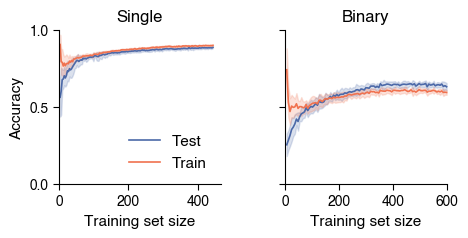

In [43]:
n_cats_single = 3
n_cats_binary = 6

fig, ax = plt.subplots(1, 2, figsize=(5, 2),
                       gridspec_kw={'wspace': 0.4},
                       sharey=True)

picks = np.arange(1, all_test_accs_single.shape[1] + 1) * n_cats_single
picks_b = np.arange(1, all_test_accs_binary.shape[1] + 1) * n_cats_binary

# Single gases
ax0 = ax[0]
mean_test = all_test_accs_single.mean(axis=0)
std_test  = all_test_accs_single.std(axis=0)
mean_train = all_train_accs_single.mean(axis=0)
std_train  = all_train_accs_single.std(axis=0)
ax0.plot(picks, mean_test, '-', color='C0', label='Test', clip_on=False)
ax0.fill_between(picks, mean_test - std_test, mean_test + std_test,
                 alpha=0.2, color='C0', clip_on=False)
ax0.plot(picks, mean_train, '-', color='C1', label='Train', clip_on=False)
ax0.fill_between(picks, mean_train - std_train, mean_train + std_train,
                 alpha=0.2, color='C1', clip_on=False)
ax0.set_xlabel('Training set size', fontsize=11)
ax0.set_ylabel('Accuracy', fontsize=11)
ax0.set_ylim(0, 1)
ax0.set_xlim(0, None)
ax0.set_ylim(0, 1)
ax0.set_xticks([0, 200, 400])
ax0.set_yticks([0, 0.5, 1])
ax0.set_title('Single', fontsize=12)
ax0.legend(loc='lower right', frameon=False, fontsize=11)

# Binary mixtures
ax1 = ax[1]
mean_test_b = all_test_accs_binary.mean(axis=0)
std_test_b  = all_test_accs_binary.std(axis=0)
mean_train_b = all_train_accs_binary.mean(axis=0)
std_train_b  = all_train_accs_binary.std(axis=0)
ax1.plot(picks_b, mean_test_b, '-', color='C0', label='Test', clip_on=False)
ax1.fill_between(picks_b, mean_test_b - std_test_b, mean_test_b + std_test_b,
                 alpha=0.2, color='C0', clip_on=False)
ax1.plot(picks_b, mean_train_b, '-', color='C1', label='Train', clip_on=False)
ax1.fill_between(picks_b, mean_train_b - std_train_b, mean_train_b + std_train_b,
                 alpha=0.2, color='C1', clip_on=False)
ax1.set_xlabel('Training set size', fontsize=11)
ax1.set_xlim(0, 600)
ax1.set_ylim(0, 1)
ax1.set_xticks([0, 200, 400, 600])
ax1.set_yticks([0, 0.5, 1])
ax1.set_title('Binary', fontsize=12)

plt.savefig('figs/few_shot_learning.pdf', bbox_inches='tight')
plt.show()

## Effect of learning rate *p*

Side-by-side comparison of *p* = 0.1 (left) and *p* = 0.01 (right).
Top row: single gases, bottom row: binary mixtures.

In [ ]:
# Load p=0.1 results
with open('data/r3_few_shot_results_p01.pkl', 'rb') as f:
    results_p01 = pickle.load(f)

single_p01 = results_p01['single']
binary_p01 = results_p01['binary']

print(f"p=0.1 params: {results_p01['params']}")
print(f"Single — shape: {single_p01['test_accs'].shape}, picks: {single_p01['n_picks']}")
print(f"Binary — shape: {binary_p01['test_accs'].shape}, picks: {binary_p01['n_picks']}")

In [ ]:
n_cats_single = 3
n_cats_binary = 6

fig, ax = plt.subplots(2, 2, figsize=(5, 4),
                       gridspec_kw={'wspace': 0.4, 'hspace': 0.5},
                       sharey=True)

# x-axes: total number of training sequences
x_single = np.arange(1, all_test_accs_single.shape[1] + 1) * n_cats_single
x_binary = np.arange(1, all_test_accs_binary.shape[1] + 1) * n_cats_binary
x_single_p01 = np.arange(1, single_p01['test_accs'].shape[1] + 1) * n_cats_single
x_binary_p01 = np.arange(1, binary_p01['test_accs'].shape[1] + 1) * n_cats_binary

# --- datasets: (row_label, p01_data, p001_data, x_p01, x_p001) ---
datasets = [
    ('Single gases', single_p01, single, x_single_p01, x_single),
    ('Binary mixtures', binary_p01, binary, x_binary_p01, x_binary),
]

for row, (row_label, data_left, data_right, x_left, x_right) in enumerate(datasets):
    for col, (data, x) in enumerate([(data_left, x_left), (data_right, x_right)]):
        a = ax[row, col]
        mt = data['test_accs'].mean(axis=0)
        st = data['test_accs'].std(axis=0)
        mr = data['train_accs'].mean(axis=0)
        sr = data['train_accs'].std(axis=0)
        a.plot(x, mt, '-', color='C0', label='Test', clip_on=False)
        a.fill_between(x, mt - st, mt + st, alpha=0.2, color='C0', clip_on=False)
        a.plot(x, mr, '-', color='C1', label='Train', clip_on=False)
        a.fill_between(x, mr - sr, mr + sr, alpha=0.2, color='C1', clip_on=False)
        a.set_xlim(0, None)
        a.set_ylim(0, 1)
        a.set_yticks([0, 0.5, 1])
        if row == 1:
            a.set_xlabel('Training set size')
        if col == 0:
            a.set_ylabel('Accuracy')

# Column titles
ax[0, 0].set_title('$p = 0.1$', fontsize=11)
ax[0, 1].set_title('$p = 0.01$', fontsize=11)

# Row labels on the right
for row, label in enumerate(['Single gases', 'Binary mixtures']):
    ax[row, 1].annotate(label, xy=(1.05, 0.5), xycoords='axes fraction',
                         fontsize=10, ha='left', va='center', rotation=-90)

# Legend on top-left panel
ax[0, 0].legend(loc='lower right', frameon=False, fontsize=10)

plt.savefig('figs/R3-few_shot_p_comparison.pdf', bbox_inches='tight')
plt.show()